 # X Sentimental Analysis

# Table of Content

# 1 Overview

CrowdFlower Twitter Band Sentiment Dataset was obtained via via data.world websites, where byweets labelled by human raters as Positive, Negative, Neutral, or I can't tell.
This project used 

## 1.1  Business Understanding

Apple and Google are two of the world's most followed technology brands on social media.  X is one of the primary platforms where consumers publicly express their opinions about products, after a product launch, a software update, a price change, or a customer service experience.
Currently, product and marketing teams at these companies rely on manual review, delayed surveys, or expensive third-party tools to understand public sentiment. This is slow, costly, and does not scale.
With over 500 million tweets sent per day globally, there is an enormous amount of real-time, unsolicited customer feedback sitting in public data,largely untapped.
An automated sentiment classifier trained on real Twitter data solves this directly. It enables teams to monitor brand perception continuously, respond to negative sentiment spikes quickly, and make data-driven product decisions.

### 1.1.0 Business Problem

Since Apple and Google product teams have no scalable, automated way to monitor whether public sentiment about their products on Twitter is positive or negative in real time.

Manual monitoring is not feasible at scale. Existing tools are generic and not trained on tech brand-specific language. There is no internal model that can read a tweet and instantly classify it as a positive or negative signal — enabling the team to act on it.

Due to this, developing a neural language processing model will help the business come up with accurate public sentiments that will help in decision making.

### 1.1.1 Objectives

1. To determine whether tweet text alone can reliably predict whether the sentiment toward an Apple or Google product is positive or negative.
2. To establish which classification algorithm performs best on this dataset — a statistical model (Logistic Regression, Naive Bayes) or a neural network (Keras/TensorFlow).
3. To evaluate how TF-IDF feature engineering compares to simple Bag-of-Words (CountVectorizer) in terms of model performance.

### 1.1.2 Research Questions

1. Can tweet text alone reliably predict whether the sentiment toward an Apple or Google product is positive or negative?
2. Which classification algorithm performs best on this dataset — a statistical model (Logistic Regression, Naive Bayes) or a neural network (Keras/TensorFlow)?
3. How does TF-IDF feature engineering compare to simple Bag-of-Words (CountVectorizer) in terms of model performance?

### 1.1.3 Success Metrics


1. Achieve a Weighted F1-score ≥ 0.80 as the primary metric to account for class imbalance between Positive (84%) and Negative (16%) tweets.
2. Achieve a Recall ≥ 0.75 for the Negative class since missing a negative tweet is more costly to the business than a false alarm.
3. Achieve a ROC-AUC ≥ 0.85 to ensure the model reliably separates Positive from Negative across all thresholds.
4. Ensure Cross-validation F1 is within 0.03 of test F1 to confirm the model generalises well and is not overfitting.


## 1.2. Data Understanding

The dataset used in this project is the CrowdFlower Twitter Brand Sentiment dataset sourced from data.world. It contains 9,093 tweets collected around the SXSW conference where both Apple and Google had a significant presence. Human raters manually labelled each tweet for sentiment.

### 1.2.0 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import re
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('omw-1.4',      quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt',        quiet=True)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, RocCurveDisplay)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from scipy.sparse import issparse
import shap
import lime
from lime.lime_text import LimeTextExplainer
from wordcloud import WordCloud
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110



### 1.2.1 Loading Dataset

In [2]:
# Load the dataset using pandas
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='latin-1')

### 1.2.2 Previewing Dataset

In [3]:
# checking the first few rows of my data
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin station...",iPhone,Negative emotion
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're ...",iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullen...",Google,Positive emotion


In [4]:
# checking columns and rows
df.shape

(9093, 3)

In [5]:
#checking data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


# NOTE:
 The dataset contains 9,093 rows and 3 text columns, with 1 missing tweet in tweettext and 5,802 missing values in emotionintweetisdirectedat since many tweets …The dataset contains 9,093 rows and 3 text columns, with 1 missing tweet in tweet_text and 5,802 missing values in emotion_in_tweet_is_directed_at since many tweets are not directed at a specific product. The target column is_there_an_emotion_directed_at_a_brand_or_product has no missing values, and all columns are object dtype meaning all features must be engineered from raw text using NLP techniques.

In [6]:
# Describing our Data
df.describe(include='all')

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #sxsw,iPad,No emotion toward brand or product
freq,5,946,5389


In [7]:
# checking for Duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 22


### 1.2.3 Data Preparation

In this section, we prepare the dataset for modelling by dropping missing values, filtering to only positive and negative tweets, encoding the target labels, and cleaning the raw tweet text using NLTK preprocessing techniques including tokenization, stopword removal and lemmatization.

### 1.2.3.1 Renaming Columns

In [8]:
df.columns = ['tweet', 'product', 'sentiment']
print(df.columns.tolist())

['tweet', 'product', 'sentiment']


### 1.2.3.2 Dropping Missing tweets

In [9]:
df.dropna(subset=['tweet'], inplace=True)
print(f'Shape after dropping missing tweet: {df.shape}')

Shape after dropping missing tweet: (9092, 3)


In [10]:
#confriming if we have any missing tweets
df.isnull().sum()

tweet           0
product      5801
sentiment       0
dtype: int64

## Note: no missing tweets

### 1.2.3.2 Filtering positive and Negative

In [11]:
binary_df = df[df['sentiment'].isin(['Positive emotion', 'Negative emotion'])].copy()
binary_df.reset_index(drop=True, inplace=True)

print(f'Binary dataset shape: {binary_df.shape}')
print('\nClass distribution:')
print(binary_df['sentiment'].value_counts())

Binary dataset shape: (3548, 3)

Class distribution:
sentiment
Positive emotion    2978
Negative emotion     570
Name: count, dtype: int64


### 1.2.3.3 Hot-encoding our Data

Making Negative and Positve in binary form

In [12]:
binary_df['label'] = (binary_df['sentiment'] == 'Positive emotion').astype(int)

print('Label encoding: Positive emotion = 1  |  Negative emotion = 0')
print(binary_df['label'].value_counts().rename({1:'Positive (1)', 0:'Negative (0)'}))

Label encoding: Positive emotion = 1  |  Negative emotion = 0
label
Positive (1)    2978
Negative (0)     570
Name: count, dtype: int64


### 1.2.3.4 Text Preprocessing Data

In [13]:
tokenizer  = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['sxsw', 'mention', 'rt', 'amp', 'via', 'http', 'co', 'ht'])

def preprocess(text):
    text = str(text).lower()                          
    text = re.sub(r'http\S+|www\S+', '', text)        
    text = re.sub(r'@\w+', '', text)                  
    text = re.sub(r'&\w+;', '', text)                 
    text = re.sub(r'#', '', text)                     
    text = re.sub(r'\d+', '', text)                   
    text = re.sub(r'[^\w\s]', '', text)               

    tokens = tokenizer.tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


### 1.2.3.5 Pre-processing data

In [14]:
binary_df['clean_tweet'] = binary_df['tweet'].apply(preprocess)

# Preview
binary_df[['tweet', 'clean_tweet', 'label']].sample(5, random_state=42)

,tweet,clean_tweet,label
299,New Post: iPad 2 Launches to Huge Lines at Apple Pop-Up Shop in Austin {link} #SXSW #SXSWi,new post ipad launch huge line apple popup shop austin link sxswi,1
2550,"RT @mention NYT app for iPad: not &quot;here's an amazing way to serve our readership,&quot; more &quot;here's a mar...",nyt app ipad here amazing way serve readership here market opportunity cant ignore newsapps,1
3080,Steve Jobs doesn't position the iPhone as a device made in China where suicide rates are high He sells dreams #Kawas...,steve job doesnt position iphone device made china suicide rate high sell dream kawasaki thisisdare,0
2342,RT @mention Google Circles will be toast if it can't convince facebook users to start an account (or interface with ...,google circle toast cant convince facebook user start account interface,0
1211,Thanks @mention for giving me new top cover for my banged up juicepack iphone case. You and your products rock! #tra...,thanks giving new top cover banged juicepack iphone case product rock tradeshow,1


In [15]:
# Confirming if data is cleaned
print(f'Total tweets for modelling: {binary_df.shape[0]}')
print(f'Missing values: {binary_df["clean_tweet"].isnull().sum()}')
print(f'Empty strings: {(binary_df["clean_tweet"] == "").sum()}')

Total tweets for modelling: 3548
Missing values: 0
Empty strings: 0


### 1.2.4 Exploratary Data Analysis

In this section, we explore the dataset visually and statistically to understand the distribution of sentiment classes, the most common words, tweet length patterns, and language structure across Apple and Google products before modelling.Both Univeriate and  Bivariate Analysis were used.

# a) Univariate Analysis

In this section, we analyse each variable individually to understand the distribution of sentiment classes, tweet lengths and the most frequently used words across the dataset before exploring relationships between variables.

## Research Q1:Can tweet text alone reliably predict whether the sentiment toward an Apple or Google product is positive or negative?

## Sentiment class distribution

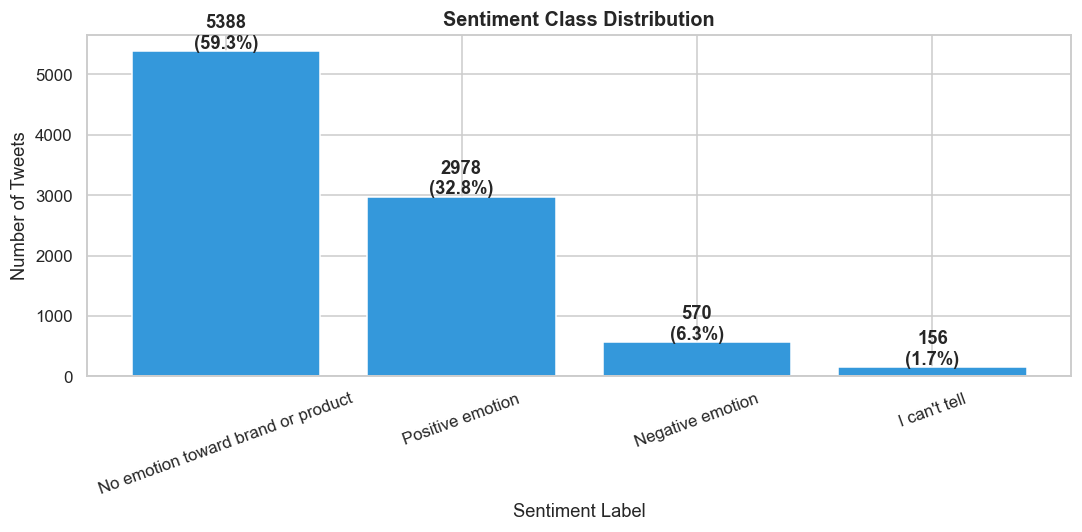

In [16]:
plt.figure(figsize=(10, 5))
sent_counts = df['sentiment'].value_counts()
total = len(df)

plt.bar(sent_counts.index, sent_counts.values, color='#3498db', edgecolor='white')
plt.title('Sentiment Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=20)
for i, v in enumerate(sent_counts.values):
    plt.text(i, v + 40, f'{v}\n({v/total*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Note:
The distribution reveals a heavily imbalanced dataset where 59.3% of tweets carry no emotion toward any brand or product, 32.7% are positive, 6.3% are negative and only 1.7% are labelled as uncertain. This confirms that predicting sentiment from text alone is a challenge, for binary classification we will retain only the 2,978 positive and 570 negative tweets, and apply class_weight='balanced' in all models to prevent the classifier from ignoring the minority negative class.

# Word clouds

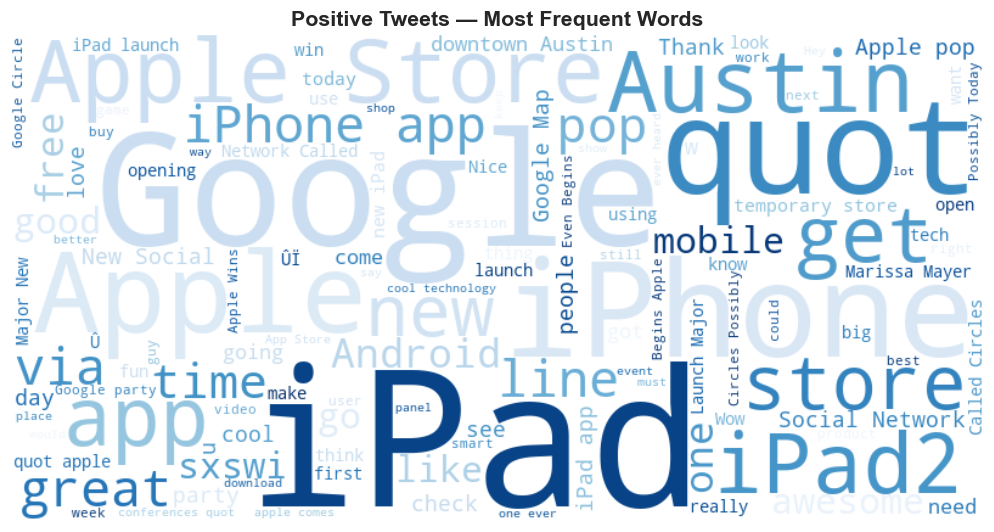

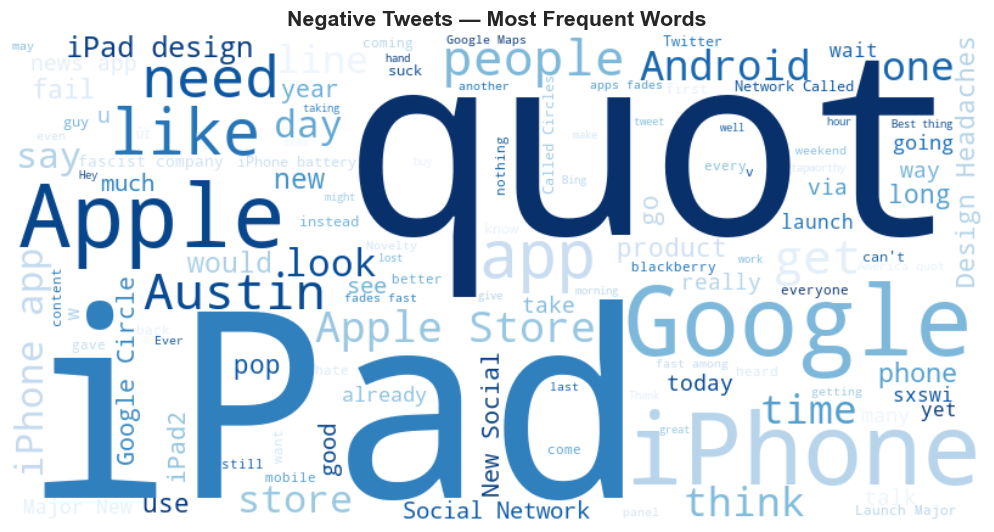

In [25]:
STOP = set(stopwords.words('english'))
STOP.update(['http','https','rt','amp','co','mention','sxsw','link','ht','ly','bit'])

def make_wordcloud(texts, title, colormap):
    combined = ' '.join(str(t) for t in texts)
    combined = re.sub(r'http\S+|@\S+', '', combined)
    wc = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=STOP, colormap=colormap, max_words=120
    ).generate(combined)
    plt.figure(figsize=(11, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

make_wordcloud(
    binary_df[binary_df['sentiment'] == 'Positive emotion']['tweet'],
    'Positive Tweets — Most Frequent Words', 'Blues'
)
make_wordcloud(
    binary_df[binary_df['sentiment'] == 'Negative emotion']['tweet'],
    'Negative Tweets — Most Frequent Words', 'Blues'
)

# NOTE:
The word clouds reveal a clear vocabulary separation between positive and negative tweets. Positive tweets are dominated by words like love, great, new, free and awesome while negative tweets contain words like fail, crash, bad and broken. This distinct difference in vocabulary between the two classes is strong visual evidence that tweet text alone contains enough signal to predict sentiment — confirming that a text-based classifier is a viable approach for this problem.

# b) Bivariate Analysis

In this section, we analyse the relationship between two variables at a time to understand how sentiment interacts with product, tweet length and language structure across the dataset.

## Research Q2:2. Which classification algorithm performs best on this dataset — a statistical model (Logistic Regression, Naive Bayes) or a neural network (Keras/TensorFlow)?

# Sentiment by Product Heatmap

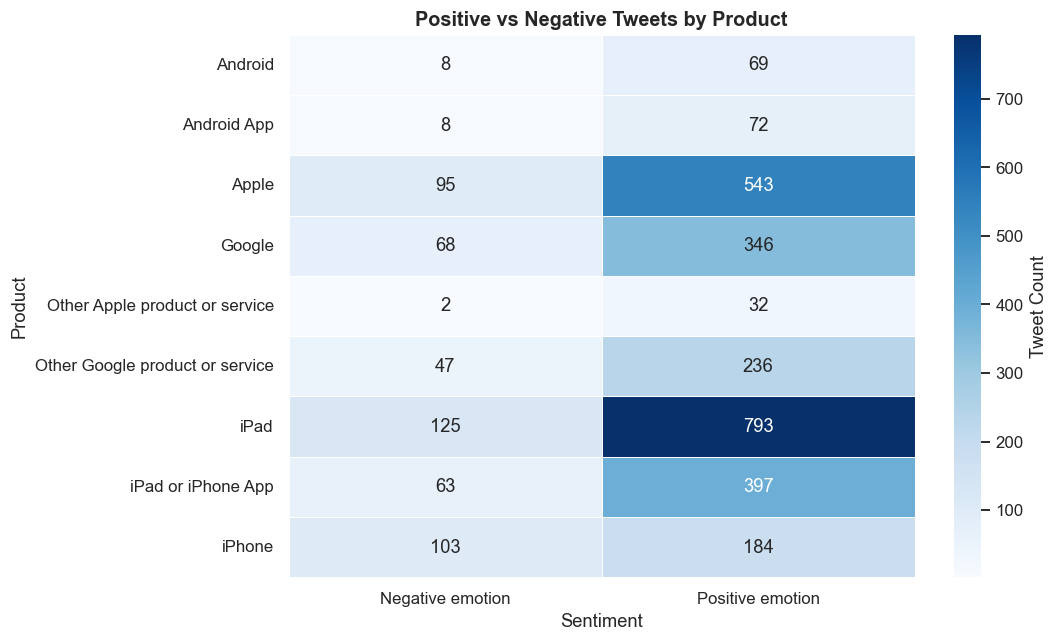

In [28]:
pos_neg = df[df['sentiment'].isin(['Positive emotion', 'Negative emotion'])].dropna(subset=['product'])
pivot = pos_neg.groupby(['product', 'sentiment']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Tweet Count'})
plt.title('Positive vs Negative Tweets by Product', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# Note:
The heatmap reveals that iPad dominates positive mentions with 793 tweets, followed by Apple with 543 and Google with 346, while iPhone has the highest negative emotion relative to its positive tweets with 103 negative out of 287 total. Android and Android App have the fewest tweets overall, suggesting limited representation in the dataset. The clear difference in intensity between positive and negative columns across all products confirms that product-specific language patterns exist in the text, supporting the case that a classifier can learn to distinguish sentiment from tweet content alone.

## Research Question 3 :How does TF-IDF feature engineering compare to simple Bag-of-Words (CountVectorizer) in terms of model performance?

# Tweet length vs sentiment



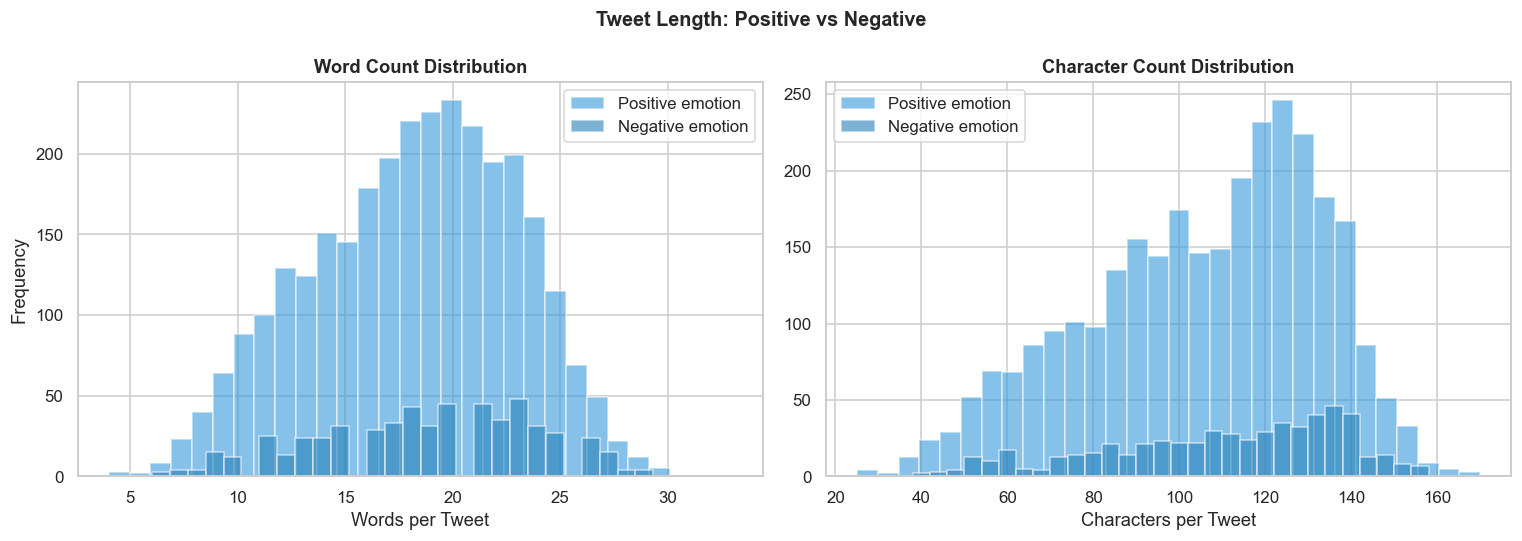

                 word_count                                            \
                      count   mean   std  min   25%   50%   75%   max   
sentiment                                                               
Negative emotion      570.0  18.76  5.08  6.0  15.0  19.0  23.0  31.0   
Positive emotion     2978.0  18.18  4.94  4.0  15.0  19.0  22.0  33.0   

                 char_count                                                  
                      count    mean    std   min   25%    50%    75%    max  
sentiment                                                                    
Negative emotion      570.0  109.45  27.39  38.0  91.0  114.0  132.0  158.0  
Positive emotion     2978.0  105.56  27.13  25.0  86.0  110.0  127.0  170.0  


In [18]:
binary_df['word_count'] = binary_df['tweet'].astype(str).apply(lambda x: len(x.split()))
binary_df['char_count'] = binary_df['tweet'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [('Positive emotion', '#3498db'), ('Negative emotion', '#2980b9')]:
    subset = binary_df[binary_df['sentiment'] == label]
    axes[0].hist(subset['word_count'], bins=30, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['char_count'], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Words per Tweet')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[1].set_title('Character Count Distribution', fontweight='bold')
axes[1].set_xlabel('Characters per Tweet')
axes[1].legend()
plt.suptitle('Tweet Length: Positive vs Negative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(binary_df.groupby('sentiment')[['word_count','char_count']].describe().round(2))

# Note:
Negative tweets have a slightly higher mean word count (18.76) and character count (109.45) compared to positive tweets (18.18 words, 105.56 characters), suggesting that users tend to write slightly longer tweets when expressing negative sentiment. Both classes have similar standard deviations meaning tweet lengths are fairly consistent across the dataset. The overlap in distributions confirms that tweet length alone is not a strong distinguishing feature — the model must rely on the actual words used, making TF-IDF a stronger feature engineering choice than Bag-of-Words since it weights unique sentiment-bearing words more heavily than common ones.

## Research Q3: Additional graph Analysis

 # POS tag spider chart

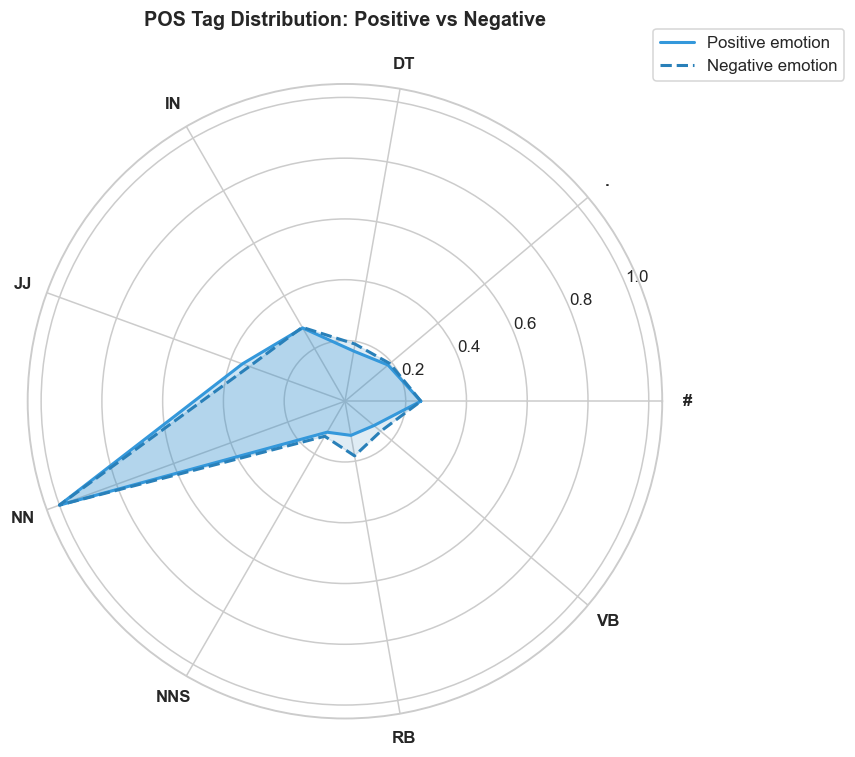

In [33]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Get top 8 POS tags
top_tags = list(set(pos_tag_counts.head(8).index) | set(neg_tag_counts.head(8).index))
top_tags = sorted(top_tags)

pos_values = [pos_tag_counts.get(tag, 0) for tag in top_tags]
neg_values = [neg_tag_counts.get(tag, 0) for tag in top_tags]

# Normalize to 0-1
pos_values_norm = [v / max(pos_values) for v in pos_values]
neg_values_norm = [v / max(neg_values) for v in neg_values]

# Number of variables
N = len(top_tags)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the circle
pos_values_norm += pos_values_norm[:1]
neg_values_norm += neg_values_norm[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, pos_values_norm, color='#3498db', linewidth=2, label='Positive emotion')
ax.fill(angles, pos_values_norm, color='#3498db', alpha=0.25)

ax.plot(angles, neg_values_norm, color='#2980b9', linewidth=2, linestyle='dashed', label='Negative emotion')
ax.fill(angles, neg_values_norm, color='#2980b9', alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top_tags, fontsize=11, fontweight='bold')
ax.set_title('POS Tag Distribution: Positive vs Negative', 
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

## NOTE:
The POS tag distribution shows that both positive and negative tweets are dominated by nouns (NN) and adjectives (JJ). Since Bag-of-Words treats all words equally, common nouns like "iPhone" and "iPad" will dominate the feature space. TF-IDF however will downweight these frequently appearing words and upweight unique sentiment-bearing adjectives like "amazing" or "broken" — making TF-IDF a more suitable feature engineering approach for this dataset. This will be confirmed in the modelling section.

# 2. Advance Modelling

In this section, we build and evaluate multiple classification models to determine which algorithm best predicts sentiment from tweet text. We begin by splitting the data, engineering text features using Bag-of-Words and TF-IDF vectorization, then train and compare models from multiple packages including scikit-learn and Keras/TensorFlow, before tuning the best model and interpreting its predictions using SHAP and LIME.

## 2.1 Spliting Data

In [32]:
X = binary_df['clean_tweet']
y = binary_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2.2 Transforming Data

In [36]:
# Bag of Words (CountVectorizer)
bow_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

In [37]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=15000, sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

In [38]:
print('Feature Engineering Summary')
print('='*45)
print(f'Bag of Words features  : {X_train_bow.shape[1]:,}')
print(f'TF-IDF features        : {X_train_tfidf.shape[1]:,}')
print(f'Training samples       : {X_train_bow.shape[0]:,}')
print(f'Test samples           : {X_test_bow.shape[0]:,}')

Feature Engineering Summary
Bag of Words features  : 10,000
TF-IDF features        : 15,000
Training samples       : 2,838
Test samples           : 710


# Note:
The Bag-of-Words vectorizer generated 10,000 features while TF-IDF generated 15,000 features from the clean tweet text. The training set contains 2,838 tweets and the test set contains 710 tweets, maintaining the 80/20 stratified split. TF-IDF generates more features because it captures unique word weightings across the corpus in addition to the raw word counts captured by Bag-of-Words.